In [1]:
from modules.dataclass import TSP

## 1. データ入力

In [2]:
tsp = TSP(file_name='burma14.tsp')
tsp.generate()

In [3]:
problem = tsp.problem
nodes = tsp.node
tsp.describe()

problem: Problem(file_name='burma14', edge_weight_type='GEO', dimension=14)
node: [Node(id=0, x_coord=16.47, y_coord=96.1), Node(id=1, x_coord=16.47, y_coord=94.44), Node(id=2, x_coord=20.09, y_coord=92.54), Node(id=3, x_coord=22.39, y_coord=93.37), Node(id=4, x_coord=25.23, y_coord=97.24), Node(id=5, x_coord=22.0, y_coord=96.05), Node(id=6, x_coord=20.47, y_coord=97.02), Node(id=7, x_coord=17.2, y_coord=96.29), Node(id=8, x_coord=16.3, y_coord=97.38), Node(id=9, x_coord=14.05, y_coord=98.12), Node(id=10, x_coord=16.53, y_coord=97.38), Node(id=11, x_coord=21.52, y_coord=95.59), Node(id=12, x_coord=19.41, y_coord=97.13), Node(id=13, x_coord=20.09, y_coord=94.55)]


## 2.前処理

In [4]:
from modules.pre_processing import Area

In [5]:
area = Area(problem=problem, nodes=nodes)
dist_matrix = area.get_dist_matrix()

## 3. 最適化

In [6]:
from modules.model_route import ModelRoute
model_route = ModelRoute(problem=problem, nodes=nodes, dist_matrix=dist_matrix)
model_route.to_optimize()
route = model_route.route
route

array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]], dtype=int8)

## 4. 可視化

In [7]:
from modules.post_proceesing import OptimizeRoute, Visualize
optimize_route = OptimizeRoute(route=route)
optimize_route.add_record()
records = optimize_route.record

In [8]:
visualize = Visualize(nodes=nodes,record=records, dist_matrix=dist_matrix)

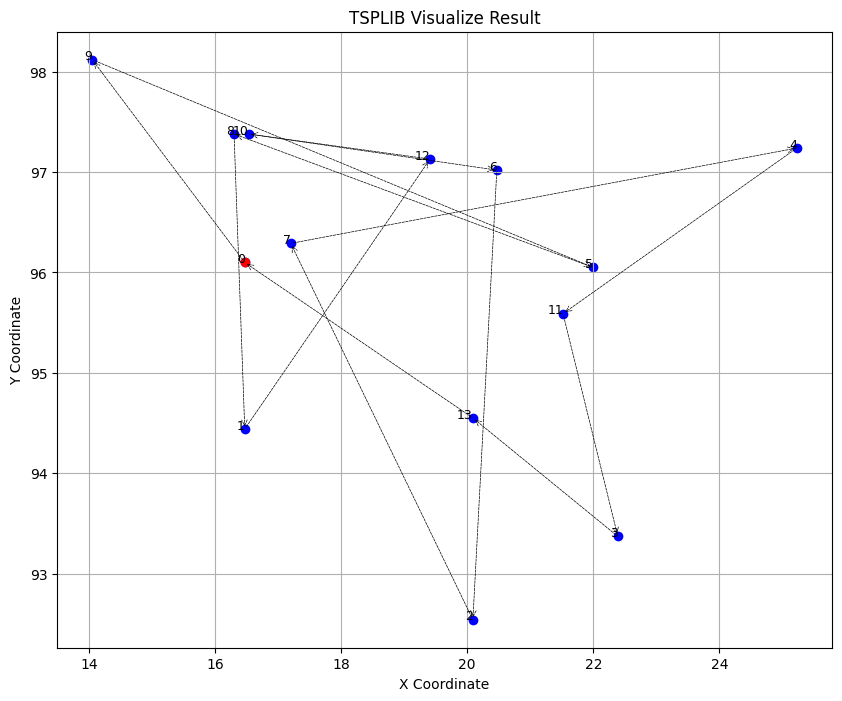

0 -> 9: 372
9 -> 5: 910
5 -> 8: 634
8 -> 1: 311
1 -> 12: 417
12 -> 10: 315
10 -> 6: 439
6 -> 2: 437
2 -> 7: 491
7 -> 4: 902
4 -> 11: 418
11 -> 3: 259
3 -> 13: 310
13 -> 0: 398
obj value = 6613


In [9]:
# 実測値
visualize.plot_route()
visualize.to_objective_value()

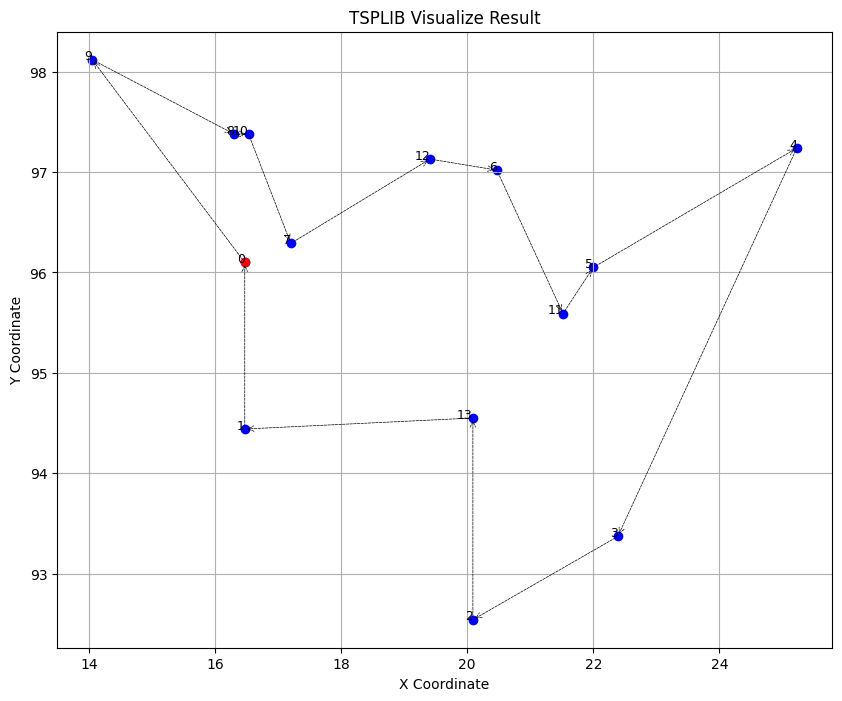

0 -> 9: 372
9 -> 8: 276
8 -> 10: 43
10 -> 7: 133
7 -> 12: 273
12 -> 6: 124
6 -> 11: 163
11 -> 5: 19
5 -> 4: 400
4 -> 3: 491
3 -> 2: 289
2 -> 13: 211
13 -> 1: 376
1 -> 0: 153
obj value = 3323


In [10]:
# 正解
visualize.plot_route(correct_ans_flg=True)
visualize.to_objective_value(correct_ans_flg=True)